# CIFAR-native resnet18 warm-up: lr sweep for confidence + logit magnitude

Question: CIFAR-native `resnet18` (src/models/resnet.py, 3x3 stride-1 stem, native
32x32 input) at warm-up `lr=0.1` gave the correct chance-level confidence (~0.1)
but logits exploded to roughly -200~300. torchvision resnet18 at 224x224 with
`lr=0.01` kept logits near 0 but confidence landed at ~0.25 instead of 0.1.

Hypothesis: logit magnitude is driven by an unconstrained "add-the-same-constant-
to-every-class-logit" direction that softmax cross-entropy never penalizes (a flat/
zero-gradient direction) -- momentum SGD randomly walks along it, and how far it
wanders scales with lr. Confidence (chance-level convergence) is a separate,
architecture-dependent question.

This notebook keeps the CIFAR-native architecture (already gets confidence right)
and drops warm-up lr to 0.01 to test whether that alone also bounds the logits.

Only the warm-up phase is tested in isolation (build model -> noise warm-up ->
measure confidence/logits on real CIFAR-10 test set). No downstream real-data
training here.

In [17]:
%matplotlib inline
import sys, os, copy, json
import torch
import torch.nn as nn
import numpy as np
import torchvision
from torch.utils.data import DataLoader

sys.path.append('..')
from src.data.degredation import get_transforms
from src.models.resnet import resnet18  # CIFAR-native (3x3 stride-1 stem, 32x32)
from src.training.random_training import random_train, random_validation
from src.evaluation.inference import get_predictions_and_confidence
from src.visualization.overconfidence_plots import plot_confidence_distribution, plot_logit_distribution

import matplotlib.pyplot as plt
from custom.figure import mm, color

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams['font.family'] = 'DejaVu Sans'


In [21]:
dir = "cifar10-native-0919"
num_net = 10

figure_dir = os.path.join("..", "figures", dir)
save_dir = os.path.join("..", "results", dir)
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

criterion = nn.CrossEntropyLoss()
num_noise, input_shape, output_size = 50000, (3, 32, 32), 10  # native CIFAR-10 resolution, no resize
batch_size = 256

dataset_dir = "../dataset"
test_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=True))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Test: {len(test_dataset)}")


Test: 10000


In [ ]:
def ckpt_path(tag, i):
    return os.path.join(save_dir, f"warmup_{tag}_{i}.pth")

def warmup_and_measure(tag, lr, epochs_noise=10, momentum=0.9, weight_decay=1e-4, seed_base=42, num_net=num_net, title=""):
    """CIFAR-native resnet18, native 32x32 input, noise warm-up at the given lr,
    then measure confidence + logit stats on real CIFAR-10 test set"""
    conf_all, logit_all = [], []

    for net_idx in range(num_net):
        torch.manual_seed(seed_base + net_idx)
        np.random.seed(seed_base + net_idx)

        model = resnet18(num_classes=output_size).to(device)

        if os.path.exists(ckpt_path(tag, net_idx)):
            model.load_state_dict(torch.load(ckpt_path(tag, net_idx), map_location=device))
            print(f"[{tag}] net {net_idx} loaded existing checkpoint, skipping warm-up")
        else:
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

            noise_loss, noise_acc = random_validation(
                model, criterion, input_shape, num_noise, batch_size, output_size, device=device)
            print(f"[{tag}] net {net_idx} warm-up epoch 0/{epochs_noise} (baseline) "
                  f"loss={noise_loss:.4f} acc={noise_acc:.4f}")

            for epoch in range(1, epochs_noise + 1):
                noise_loss, noise_acc = random_train(
                    model, optimizer, criterion, input_shape, num_noise, batch_size, output_size, device=device)
                print(f"[{tag}] net {net_idx} warm-up epoch {epoch}/{epochs_noise} "
                      f"loss={noise_loss:.4f} acc={noise_acc:.4f}")

            torch.save(model.state_dict(), ckpt_path(tag, net_idx))

        _, conf, _, _, logit = get_predictions_and_confidence(
            model, test_loader, device=device, return_logits=True)
        per_sample_range = logit.max(axis=1) - logit.min(axis=1)

        print(f"[{tag}] net {net_idx} confidence: mean={conf.mean():.4f} std={conf.std():.4f}  "
              f"(chance=1/{output_size}={1/output_size:.4f})")
        print(f"[{tag}] net {net_idx} logit (raw): min={logit.min():.2f} max={logit.max():.2f} "
              f"mean={logit.mean():.2f} std={logit.std():.2f}")
        print(f"[{tag}] net {net_idx} logit per-sample range (max-min across classes): "
              f"mean={per_sample_range.mean():.2f} std={per_sample_range.std():.2f}")

        conf_all.append(conf)
        logit_all.append(logit)

    conf_all = np.concatenate(conf_all)
    logit_all = np.concatenate(logit_all)
    chance = 1 / output_size

    plot_confidence_distribution(conf_all, color["sky"], title, chance_level=chance)
    plot_logit_distribution(logit_all, color["sky"], title)

    return conf_all, logit_all


[native_lr0.1_r0] net 0 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r0] net 0 confidence: mean=0.9990 std=0.0083  (chance=1/10=0.1000)
[native_lr0.1_r0] net 0 logit (raw): min=-47.00 max=68.99 mean=3.05 std=14.16
[native_lr0.1_r0] net 0 logit per-sample range (max-min across classes): mean=47.03 std=13.55
[native_lr0.1_r0] net 1 loaded existing checkpoint, skipping warm-up
[native_lr0.1_r0] net 1 confidence: mean=0.9353 std=0.1116  (chance=1/10=0.1000)
[native_lr0.1_r0] net 1 logit (raw): min=-232.86 max=102.59 mean=-1.98 std=37.63
[native_lr0.1_r0] net 1 logit per-sample range (max-min across classes): mean=121.33 std=39.74
[native_lr0.1_r0] net 2 warm-up epoch 0/0 (baseline) loss=31.0863 acc=0.1004
[native_lr0.1_r0] net 2 confidence: mean=0.9008 std=0.1323  (chance=1/10=0.1000)
[native_lr0.1_r0] net 2 logit (raw): min=-34.51 max=81.69 mean=2.14 std=16.33
[native_lr0.1_r0] net 2 logit per-sample range (max-min across classes): mean=46.79 std=12.91
[native_lr0.1_r0] net 

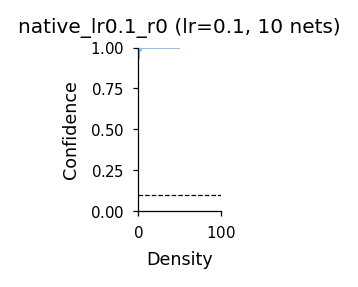

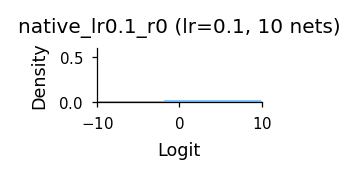

[native_lr0.1_r1] net 0 warm-up epoch 0/1 (baseline) loss=22.5794 acc=0.0994


KeyboardInterrupt: 

In [25]:
epochs_noise_list = [0, 1, 2, 3, 4, 5, 7, 10]

sweep_conf = {}
sweep_logit = {}
for r in epochs_noise_list:
    conf, logit = warmup_and_measure(f"native_lr0.1_r{r}", lr=0.1, epochs_noise=r, num_net=10, title=f"r{r}")
    sweep_conf[r] = conf
    sweep_logit[r] = logit


In [ ]:
sweep_means = [sweep_conf[r].mean() for r in epochs_noise_list]
sweep_stds = [sweep_conf[r].std() for r in epochs_noise_list]
chance = 1 / output_size

plt.figure(figsize=(60 * mm, 40 * mm))
plt.errorbar(epochs_noise_list, sweep_means, yerr=sweep_stds, fmt='o-', color=color["sky"], capsize=3)
plt.axhline(y=chance, color='k', linestyle='--', linewidth=0.5)
plt.xlabel("warm-up epochs (r)")
plt.ylabel("mean confidence")
plt.title("Confidence vs warm-up epochs (native, lr=0.1, 10 nets)")
plt.legend()
plt.savefig(os.path.join(figure_dir, "confidence_vs_epochs_noise.svg"))
plt.show()

print(f"{'r':<5}{'mean conf':<12}{'std':<10}")
for r, m, s in zip(epochs_noise_list, sweep_means, sweep_stds):
    print(f"{r:<5}{m:<12.4f}{s:<10.4f}")

SyntaxError: unterminated string literal (detected at line 10) (2971039030.py, line 10)